In [1]:
import netCDF4
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timezone
import math
import cmocean
from geopy import distance
from scipy.stats import cumfreq
from scipy.interpolate import griddata
import shapefile
from functions import *


%matplotlib widget 
# Autosave every second:
%autosave 1

Autosaving every 1 seconds


In [2]:
folder = "../data/Level2B_TD"
files = os.listdir(folder)
files.sort()

In [3]:
# fig,ax = plt.subplots(figsize=(20,10))
# for file in files:
#     nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
#     z = nc.variables["prho"][:]
#     t = nc.variables["time"][:]
#     d = nc.variables["depth_ref"][:]
#     x,y = np.meshgrid(t, d)
#     c = ax.pcolormesh(x,y,z,cmap='jet', vmin=5, vmax=25)
#     nc.close()
# ax.invert_yaxis()
# fig.colorbar(c, ax=ax)

In [4]:
coord_KivuWatt=[29.202352,-2.087932]
coord_KP1=[29.242921,-1.732214]

# 1. Bathymetry

## 1.1. Contour data

In [6]:
# Bathymetry (coordinates are not lat and lon!)
sf = shapefile.Reader("../../../Bathymetry/Kivu_bath_WGS84.shp")
contour_data=sf.shapes()
attributes_data=sf.records()

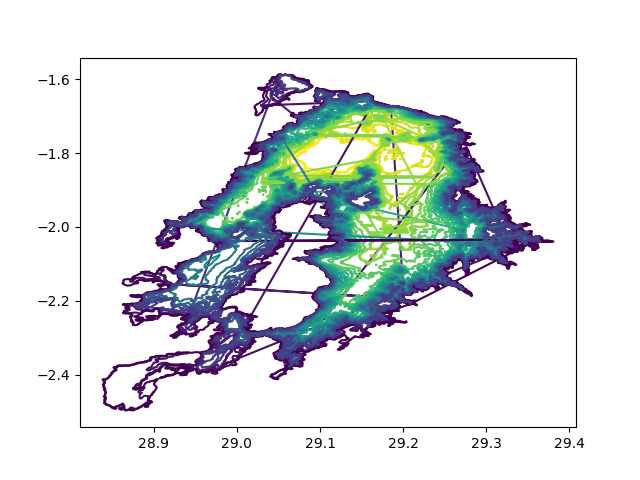

In [7]:
fig,ax=plt.subplots()
xval=[]
yval=[]
zval=np.full(len(contour_data),np.nan)
for k in np.arange(0,len(contour_data),1):
    xval.append([i[0] for i in contour_data[k].points[:]])
    yval.append([i[1] for i in contour_data[k].points[:]])
    zval[k]=attributes_data[k][-1]
#     if zval[k]==20:
#         ax.plot(xval[k],yval[k],'.-')
zval_unique=np.unique(zval)

colval=plt.get_cmap('viridis',len(zval_unique))
for k in np.arange(0,len(contour_data),1):
    ax.plot(xval[k],yval[k],'-',color=colval(np.where(zval_unique==zval[k])[0]))
                    

**Issue**: <font color='red'>points from the contour lines are not in the right order.</font>

## 1.2. Grid data

In [67]:
# Bathymetry grid
df=pd.read_csv('../../../Bathymetry/Kivu_blend.xyz', header=0, names=['long','lat','z'],sep="\t",index_col=False,skiprows=1)

In [84]:
X,Y=np.mgrid[df["long"].min():df["long"].max():0.001,df["lat"].min():df["lat"].max():0.001]

longval=df["long"].values[np.arange(0,len(df["long"]),1000)]
latval=df["lat"].values[np.arange(0,len(df["long"]),1000)]
zval=df["z"].values[np.arange(0,len(df["long"]),1000)]

long_shore=df["long"].values[df["z"].values>-5]
lat_shore=df["lat"].values[df["z"].values>-5]


In [85]:
Z=griddata((longval,latval), zval, (X,Y), method='linear')

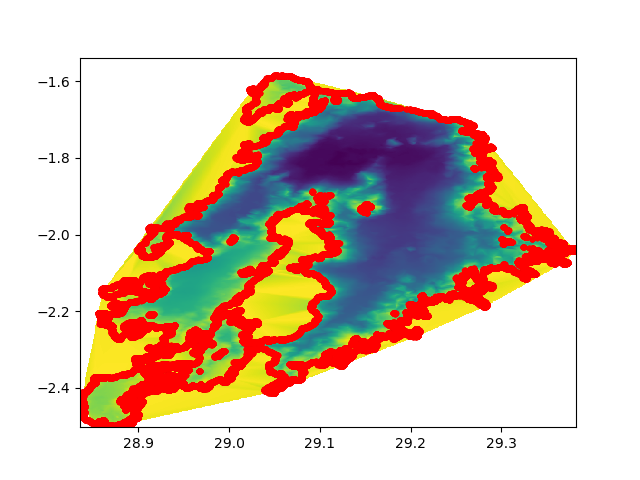

In [86]:
fig,ax=plt.subplots()
ax.pcolormesh(X,Y,Z)
ax.plot(long_shore,lat_shore,'r.')

**Issue**: <font color='red'>no 0m-contour line to remove interpolation outside lake boundaries &rarr; create a polygon from red points?</font>

# 2. Metadata & coordinates/distance comparison

### Read metadata file

In [86]:
date_sheets=list(map(str,np.arange(2008,2023,1)))
df = pd.read_excel('../data/meta_data/0_CTD information_2008-2022_ms_221201.xlsx',sheet_name=date_sheets)

In [87]:
meta_date=[]
meta_prof=[]
meta_lat=[]
meta_long=[]
meta_dist=[]
for date_name in date_sheets:
    if date_name in ['2008','2009']:
        # Add "0":
        dateval=pd.to_datetime('0' + df[date_name][1:].date.astype(int).astype(str),format= "%y%m%d")
    else:
        dateval=pd.to_datetime(df[date_name][1:].date,format= "%y%m%d")   
    meta_date.extend(dateval.tolist()) 
    meta_prof.extend(df[date_name]['Profile count'][1:].tolist()) 
    meta_lat.extend(df[date_name]['Latitude S (digital)'][1:].tolist()) 
    meta_long.extend(df[date_name]['Longitude E(digital)'][1:].tolist()) 
    meta_dist.extend(df[date_name]['Distance to GEF (m)'][1:].tolist())
meta_date=np.array(meta_date)
meta_prof=np.array(meta_prof)
meta_lat=np.array(meta_lat)
meta_long=np.array(meta_long)
meta_dist=np.array(meta_dist) 

In [88]:
dist_KP1=[]
dist_KW=[]
for k in np.arange(0,len(meta_prof),1):
    if meta_lat[k]<-90 or meta_lat[k]>90:
        print('Error with latitude value')
        dist_KP1.append(np.nan)
        dist_KW.append(np.nan)
        
    dist_KP1.append(distance.distance((meta_lat[k],meta_long[k]),(coord_KP1[1],coord_KP1[0])).km*1000)
    dist_KW.append(distance.distance((meta_lat[k],meta_long[k]),(coord_KivuWatt[1],coord_KivuWatt[0])).km*1000)
dist_both=np.array([np.abs(meta_dist-dist_KP1),np.abs(meta_dist-dist_KW)])
dist_best=dist_both[np.argmin(dist_both,axis=0),np.arange(len(meta_lat))]

dist_diffrel=(dist_best-meta_dist)/1000 # km
dist_diff=np.abs(dist_diffrel)/1000 # km
# Find profiles that have potentially wrong coordinates
ind_wrong=np.where(dist_diff/1000>1)

# Cumulative distribution
cum_dist = cumfreq(dist_diff[~np.isnan(dist_diff)],1000)
x=cum_dist.lowerlimit+np.arange(0,cum_dist.lowerlimit+cum_dist.binsize*len(cum_dist.cumcount),cum_dist.binsize)

# Distance below which 90% of the points are
dist_diffrel_sort=np.sort(dist_diffrel)
dist_diffrel_sort=dist_diffrel_sort[~np.isnan(dist_diffrel_sort)] # Remove NaN values
dist_diff_sort=np.sort(dist_diff)
dist_diff_sort=dist_diff_sort[~np.isnan(dist_diff_sort)] # Remove NaN values
cum_prob_rel=np.arange(1,len(dist_diffrel_sort)+1,1)/len(dist_diffrel_sort)
cum_prob=np.arange(1,len(dist_diff_sort)+1,1)/len(dist_diff_sort)
ind90=np.where(cum_prob>0.9)[0][0]

# Probability of having a distance less than 1 km
ind1km=np.where(dist_diff_sort>1)[0][0]

### Compare distance provided with distance from coordinates

Text(0, 0.5, 'Cumulative distribution')

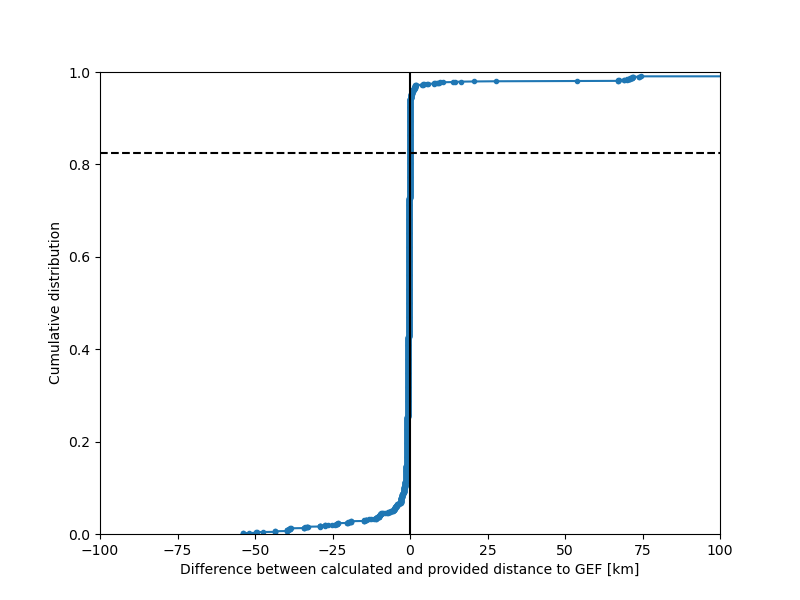

In [89]:
fig,ax=plt.subplots(figsize=(8,6))
ax.plot(dist_diffrel_sort,cum_prob_rel,'.-')
ax.set_xlim(-100,100)
ax.set_ylim(0,1)
prob_change_sign=cum_prob_rel[np.where(dist_diffrel_sort>=0)[0][0]]
ax.plot([0,0],[0,1],'-k')
ax.plot([-100,100],[prob_change_sign,prob_change_sign],'--k')
ax.set_xlabel('Difference between calculated and provided distance to GEF [km]')
ax.set_ylabel('Cumulative distribution')

&rarr; Less than 20% of the provided coordinates are further from the platform than expected from the provided distance but they  lead to larger errors (>100 km).

In [91]:
fig.savefig("Figures/distance_GEF_diff.png",dpi=400)

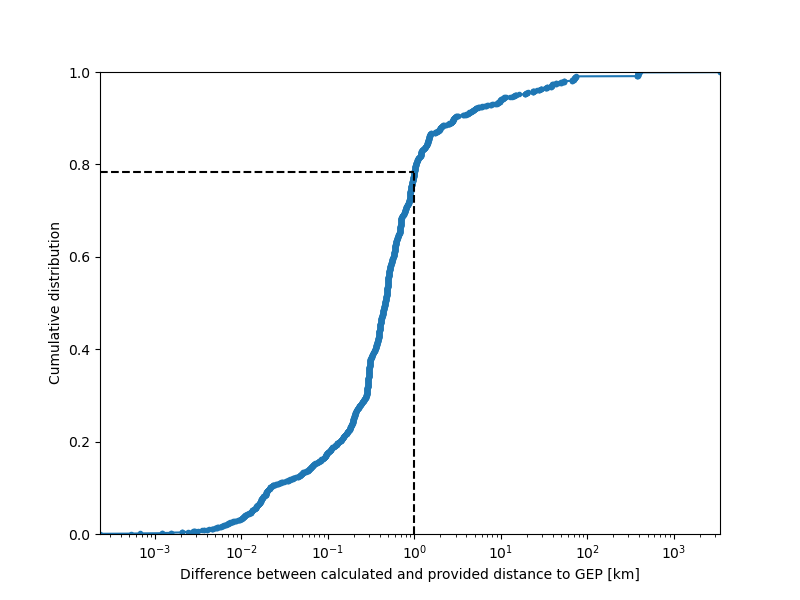

In [44]:
fig,ax=plt.subplots(figsize=(8,6))
ax.plot(dist_diff_sort,cum_prob,'.-')
#ax.plot([dist_diff_sort[ind90],dist_diff_sort[ind90]],[0,cum_prob[ind90]],'--k')
#ax.plot([np.nanmin(dist_diff_sort),dist_diff_sort[ind90]],[cum_prob[ind90],cum_prob[ind90]],'--k')
ax.plot([dist_diff_sort[ind1km],dist_diff_sort[ind1km]],[0,cum_prob[ind1km]],'--k')
ax.plot([np.nanmin(dist_diff_sort),dist_diff_sort[ind1km]],[cum_prob[ind1km],cum_prob[ind1km]],'--k')
ax.set_xscale('log')
ax.set_xlim(np.nanmin(dist_diff_sort),np.nanmax(dist_diff_sort))
ax.set_ylim(0,1)
ax.set_xlabel('Difference between calculated and provided distance to GEF [km]')
ax.set_ylabel('Cumulative distribution')
#ax.bar(x, cum_dist.cumcount, width=cum_dist.binsize,align='edge')

fig.savefig("Figures/distance_GEF.png",dpi=400)

**Summary**: More than 20% of the points are located more than 1 km further than the provided distance.

Number of zero distances:256


Text(0.5, 1.0, 'Distances = 0')

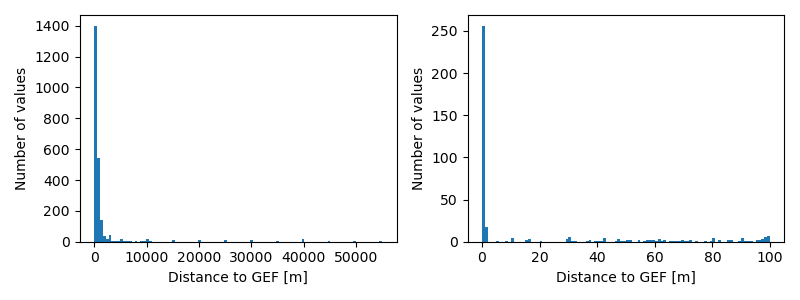

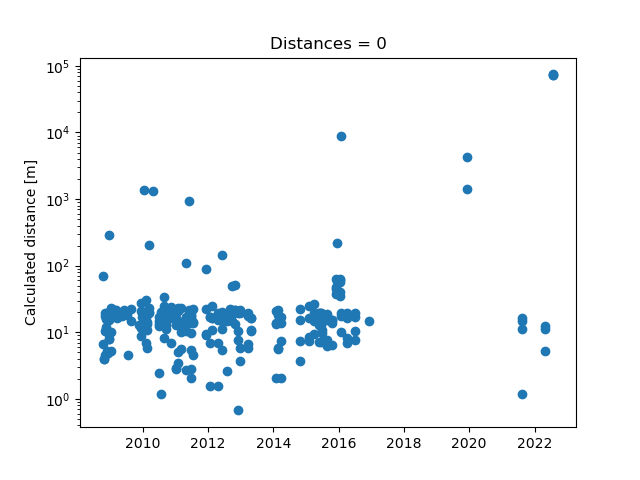

In [94]:
# Statistics provided distance to GEF
print('Number of zero distances:'+str(len(meta_dist[meta_dist==0])))
dates_zerodist=meta_date[meta_dist==0]
#print(dates_zerodist)

fig1,ax=plt.subplots(1,2,figsize=(8,3))

ax[0].hist(meta_dist,bins=100)
ax[0].set_xlabel('Distance to GEF [m]')
ax[0].set_ylabel('Number of values')

#ax[1].hist(meta_dist[meta_dist<100],bins=100)
ax[1].hist(meta_dist,bins=100,range=(0,100))
ax[1].set_xlabel('Distance to GEF [m]')
ax[1].set_ylabel('Number of values')
plt.tight_layout()

fig2,ax=plt.subplots()
ax.plot(meta_date[meta_dist==0],dist_best[meta_dist==0],'o')
ax.set_ylabel('Calculated distance [m]')
ax.set_yscale('log')
ax.set_title('Distances = 0')



**Summary**: the provided distance is equal to zero for 256 profiles (could correspond to profiles taken directly from the platform). Most of these profiles also have coordinates that match the platform location (+/- 100 m), except for ~7 outliers.

In [95]:
fig1.savefig("Figures/distance_GEF_hist.png",dpi=400)
#fig2.savefig("Figures/distance_GEF_zero.png",dpi=400)

In [71]:
#Export the locations:
df_loc_meta=pd.DataFrame({"Profile_index":np.arange(1,len(meta_long)+1,1),"Log_dist_diff_km":np.log10(dist_diff),"Longitude":meta_long,"Latitude":meta_lat})

In [73]:
df_loc_meta.to_csv('locations_profiles_all.csv',sep=',',index=False)

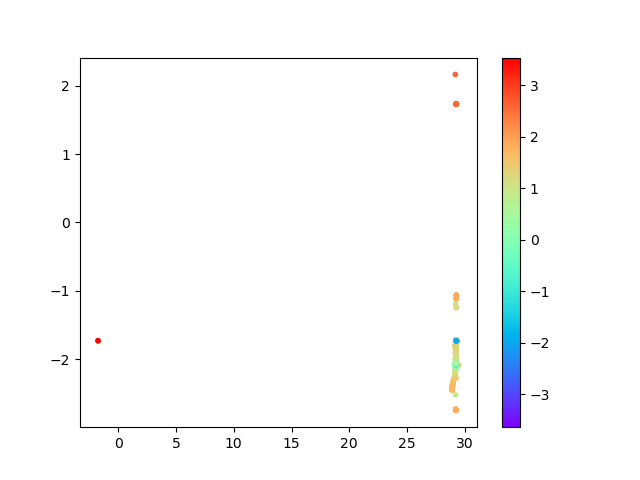

In [72]:
fig,ax=plt.subplots()
#ax.plot(df_loc_meta["Longitude"],df_loc_meta["Latitude"],'.')
pscat=ax.scatter(df_loc_meta["Longitude"],df_loc_meta["Latitude"],c=df_loc_meta["Log_dist_diff_km"],marker='.',cmap='rainbow')
plt.colorbar(pscat)

# 3.a. All raw profiles (Level 2A)

In [50]:
foldername='../data/Level2A_TD/'
filename_list=os.listdir(foldername)

### Detect conductivity peak

In [85]:
tyear_all=np.arange(2008,2023,1)
airpress=[]
press_firstpeak=[]
press_lastpeak=[]
tdate_prof=[]
filename_prof=[]
diffcond_prof=[]

for kyear in tyear_all:
    files_year=[i for i in filename_list if 'L2A_'+str(kyear) in  i]
    print('Year '+str(kyear))
    for kprof in np.arange(len(files_year)):
        nc=netCDF4.Dataset(foldername+files_year[kprof], mode='r', format='NETCDF4_CLASSIC')
        t = nc.variables["time"][:]
        cond=nc.variables["Cond"][:]
        press = nc.variables["Press"][:] 
        t_date= np.array([datetime.utcfromtimestamp(k) for k in t.data])
        filename_prof.append(files_year[kprof])
        nc.close()
        
        diff_cond = abs(first_centered_differences(np.arange(len(cond)), cond))
        diffcond_prof.append(diff_cond)
        perc_cond = np.where(diff_cond > np.percentile(diff_cond, 95))
        #perc_cond_begin = np.where(diff_cond[:max_start] > np.percentile(diff_cond, 95))
        airpress.append(np.nanmin(press))
        press_firstpeak.append(press[perc_cond[0][0]])
        press_lastpeak.append(press[perc_cond[0][-1]])
        tdate_prof.append(t_date[0])

Year 2008
Year 2009
Year 2010
Year 2011
Year 2012
Year 2013
Year 2014
Year 2015
Year 2016
Year 2017
Year 2018
Year 2019
Year 2020
Year 2021
Year 2022


### Profiles with missing peak

In [102]:
ind_prof_nopeak1=np.where(np.array(press_firstpeak)-airpress>1)[0]
tdate_nopeak1=[tdate_prof[i] for i in ind_prof_nopeak1]
press_nopeak1=[press_firstpeak[i] for i in ind_prof_nopeak1]
print(str(len(ind_prof_nopeak1))+" profiles without first conductivity peak")

ind_prof_nopeak=np.where(np.logical_and(np.array(press_firstpeak)-airpress>1,np.array(press_lastpeak)-airpress>1))[0]
tdate_nopeak=[tdate_prof[i] for i in ind_prof_nopeak]
press_nopeak=[press_lastpeak[i] for i in ind_prof_nopeak]
print(str(len(ind_prof_nopeak))+" profiles without conductivity peak")

42 profiles without first conductivity peak
5 profiles without conductivity peak


### Figure conductivity peak

Text(0, 0.5, 'Pressure at the last peak [dbar]')

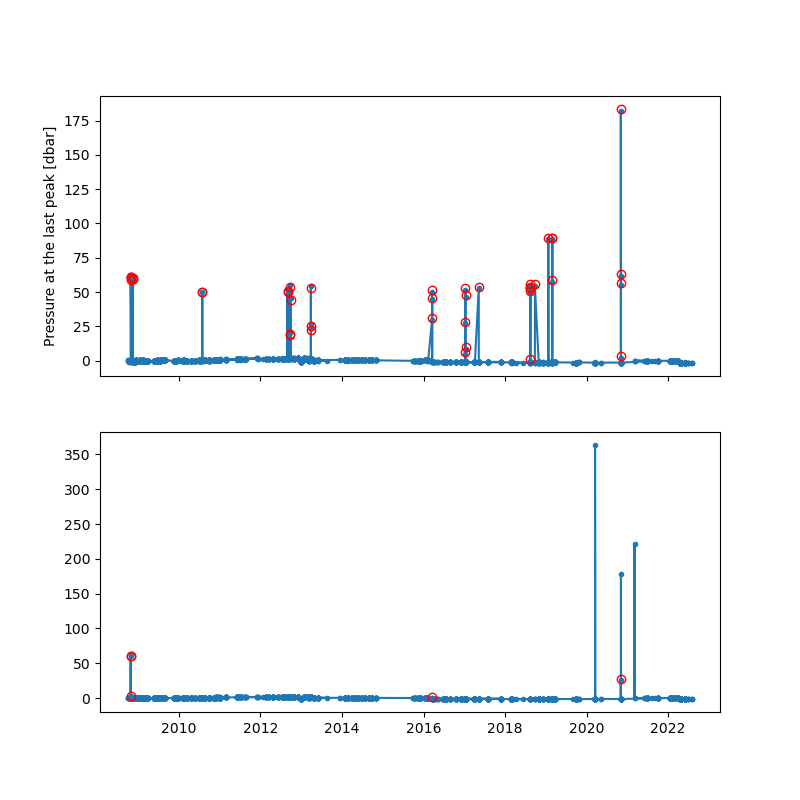

In [110]:
fig,ax=plt.subplots(2,1,figsize=(8,8),sharex=True)

ax[0].plot(tdate_prof,press_firstpeak,'.-')
ax[0].plot(tdate_nopeak1,np.array(press_nopeak1)-np.array([airpress[i] for i in ind_prof_nopeak1]),'ro',markerfacecolor='none')
ax[0].set_ylabel('Pressure at the first peak [dbar]')
ax[1].plot(tdate_prof,press_lastpeak,'.-')
ax[1].plot(tdate_nopeak,np.array(press_nopeak)-np.array([airpress[i] for i in ind_prof_nopeak]),'ro',markerfacecolor='none')
ax[0].set_ylabel('Pressure at the last peak [dbar]')

### Figure example profile without a conductivity peak

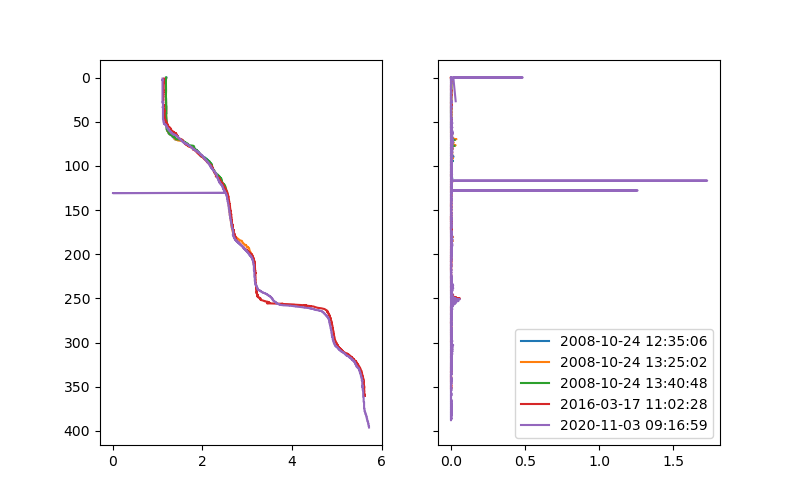

In [115]:
fig,ax=plt.subplots(1,2,figsize=(8,5),sharey=True)
#kprof=0
for kprof in np.arange(len(ind_prof_nopeak)):
    nc=netCDF4.Dataset(foldername+filename_prof[ind_prof_nopeak[kprof]], mode='r', format='NETCDF4_CLASSIC')
    cond=nc.variables["Cond"][:]
    press = nc.variables["Press"][:] 
    temp=nc.variables["Temp"][:] 
    depth=nc.variables["depth"][:] 
    nc.close()
    
    #ax[0].plot(cond[:np.argmax(press)],press[:np.argmax(press)]-np.nanmin(press))
    #ax[0].plot(cond[np.argmax(press):],press[np.argmax(press):]-np.nanmin(press))
    #ax[0].plot(cond,press-np.nanmin(press))
    ax[0].plot(cond,depth)
    
    ax[1].plot(diffcond_prof[ind_prof_nopeak[kprof]],press-np.nanmin(press))
ax[0].invert_yaxis()
#plt.legend(ind_prof_nopeak)
plt.legend(tdate_nopeak)

### Figure profiles 

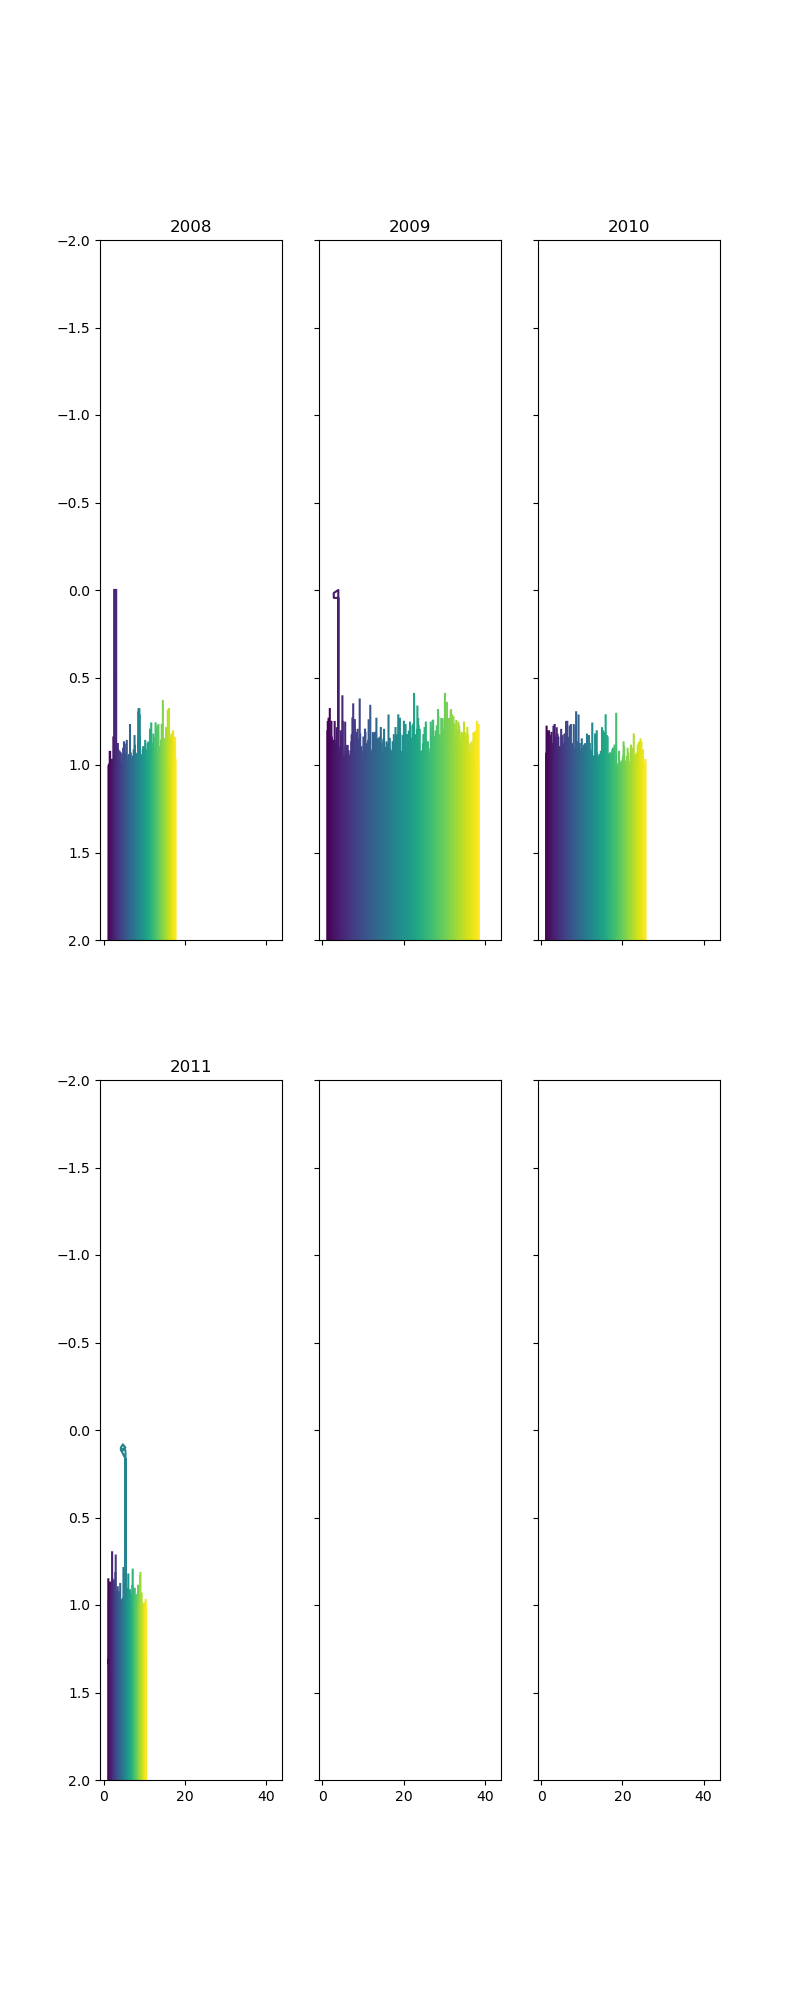

In [14]:
#tyear=np.arange(2008,2023,1)
tyear=np.array([2008,2009,2010,2011])
ylimval=[-10,370]
#xlimval=[997.5,1001]
fig,ax = plt.subplots(math.ceil(len(tyear)/3),3,figsize=(8,20),sharex='all',sharey='all')
count=0
dcond=0.1

for kyear in tyear:
    krow=math.floor(count/3)
    kcol=count%3 # Modulo
    files_year=[i for i in filename_list if 'L2A_'+str(kyear) in  i]
    Cmap=plt.get_cmap('viridis',len(files_year))
    for kprof in np.arange(len(files_year)):
        nc=netCDF4.Dataset(foldername+files_year[kprof], mode='r', format='NETCDF4_CLASSIC')
        t = nc.variables["time"][:]
        temp = nc.variables["Temp"][:]
        cond=nc.variables["Cond"][:]
        press = nc.variables["Press"][:]
        press_qual = nc.variables["Press_qual"][:]
        depth = nc.variables["depth"][:]
        t_date= np.array([datetime.utcfromtimestamp(k) for k in t.data])
        nc.close()
        # Plot:
        indbot=np.argmax(press)
        hplot,=ax[krow,kcol].plot(cond[:indbot]+kprof*dcond,depth[:indbot],color=Cmap(kprof))
    ax[krow,kcol].set_title(str(kyear))
    ax[krow,kcol].set_ylim(ylimval[0],ylimval[1])
    #ax[krow,kcol].set_xlim(xlimval[0],xlimval[1])
    ax[krow,kcol].set_ylim(-2,2)
    ax[krow,kcol].invert_yaxis()
    count=count+1

# 3. All the deep profiles (Level 2B = depth-interpolated)

### Combine all the profiles deeper than the main chemocline

In [29]:
first = True
dmin=260
#dmin=1
for file in files:
    nc = netCDF4.Dataset(os.path.join(folder, file), mode='r', format='NETCDF4_CLASSIC')
    d = nc.variables["depth_ref"][:] 
    rho = nc.variables["rho"][:]
    indkeep=[]
    # Remove small profiles:
    for kprof in np.arange(0,len(rho[0]),1):
        if np.max(d[np.logical_not(np.isnan(rho[:,kprof]))])>dmin:
            indkeep.append(kprof)                    
    
    rho_keep=rho[:,indkeep]
    if first:
        rho_all = rho_keep
        t_all = nc.variables["time"][indkeep] 
        temp_all = nc.variables["Temp"][:,indkeep]
        cond_all = nc.variables["Cond"][:,indkeep]
        turb_all = nc.variables["Turb"][:,indkeep] 
        pH_all = nc.variables["pH"][:,indkeep]
        DO_all = nc.variables["DO_mg"][:,indkeep]
        d_all = d
        #lat_all=nc.variables["latitude"][indkeep]
        #long_all=nc.variables["longitude"][indkeep]
        first = False
    else:
        rho_all = np.concatenate((rho_all, rho_keep), axis=1) 
        t_all = np.concatenate((t_all, nc.variables["time"][:][indkeep]), axis=0)
        temp_all = np.concatenate((temp_all, nc.variables["Temp"][:][:,indkeep]), axis=1) 
        cond_all = np.concatenate((cond_all, nc.variables["Cond"][:][:,indkeep]), axis=1) 
        turb_all = np.concatenate((turb_all, nc.variables["Turb"][:][:,indkeep]), axis=1)
        pH_all = np.concatenate((pH_all, nc.variables["pH"][:][:,indkeep]), axis=1) 
        DO_all = np.concatenate((DO_all, nc.variables["DO_mg"][:][:,indkeep]), axis=1)
        #lat_all=np.concatenate((lat_all,nc.variables["latitude"][:][indkeep]),axis=0)
        #long_all=np.concatenate((long_all,nc.variables["longitude"][:][indkeep]),axis=0)
    nc.close()

t_date_all = np.array([datetime.utcfromtimestamp(k) for k in t_all.data])




In [30]:
# Remove wrong profiles on 17.03.2020
valrem=np.logical_and(t_date_all>datetime(2020,3,17),t_date_all<datetime(2020,3,18))
rho_all=np.delete(rho_all,valrem,axis=1)
t_all=np.delete(t_all,valrem)
temp_all=np.delete(temp_all,valrem,axis=1)
cond_all=np.delete(cond_all,valrem,axis=1)
turb_all=np.delete(turb_all,valrem,axis=1)
pH_all=np.delete(pH_all,valrem,axis=1)
DO_all=np.delete(DO_all,valrem,axis=1)
t_date_all=np.delete(t_date_all,valrem)

In [31]:
x,y = np.meshgrid(t_date_all, d_all)

In [32]:
# Compute chemocline depth from density, temperature, conductivity
ind_deep=np.where(d_all>200)[0]
rho_deep=rho_all[ind_deep,:]
z_rhomax=d_all[ind_deep[np.argmax(np.diff(rho_deep,axis=0),axis=0)]+1] # Differences between rows (depth)
z_rhomax2=d_all[ind_deep[np.argmax(np.gradient(rho_deep,axis=0),axis=0)]] # Differences between rows (depth)


### Plot profile locations

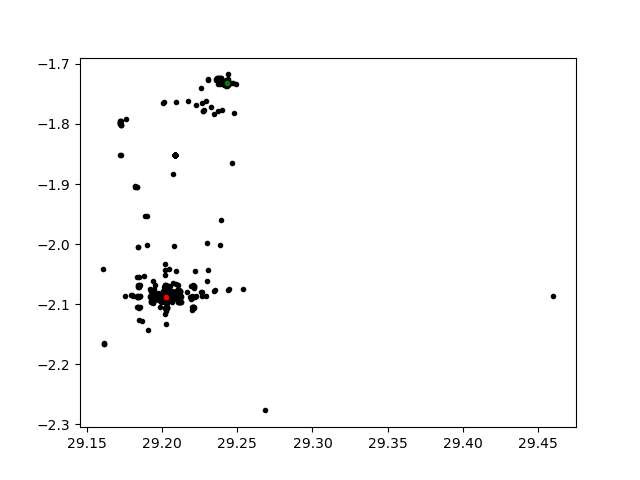

In [14]:
fig,ax=plt.subplots()
ax.plot(long_all,lat_all,'k.')
#ax.plot(meta_long,meta_lat,'b.')
ax.plot(coord_KivuWatt[0],coord_KivuWatt[1],'.r')
ax.plot(coord_KP1[0],coord_KP1[1],'.g')

### Export profile locations (for map in Google Earth)

In [14]:
df_loc=pd.DataFrame({"Profile_index":np.arange(1,len(long_all)+1,1),"Longitude":long_all,"Latitude":lat_all})

In [17]:
df_loc.to_csv('locations_profiles_deep.csv',sep=',',index=False)

### Figure grid

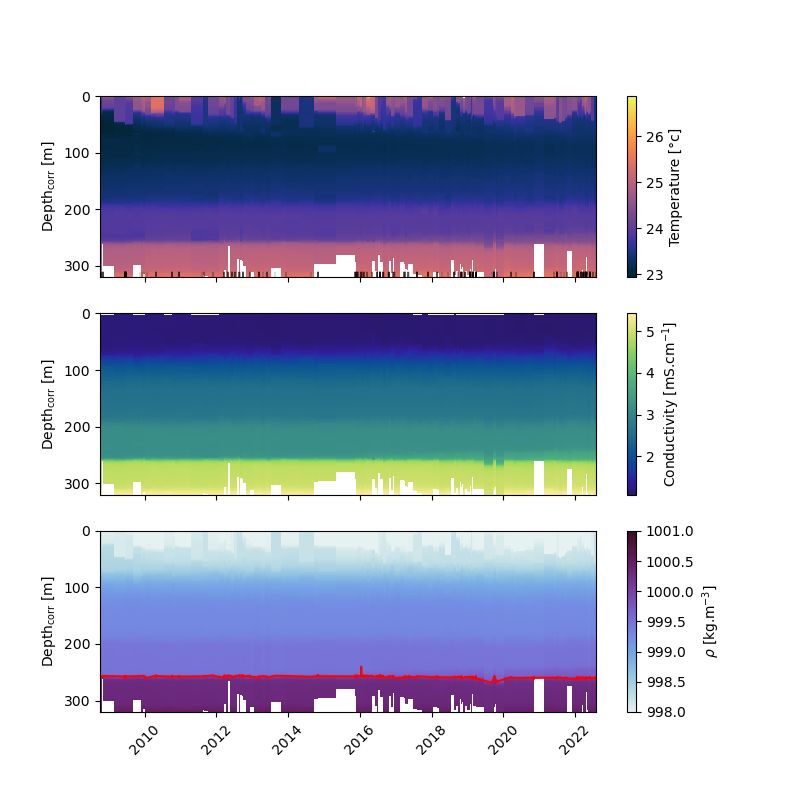

In [36]:
fig,ax = plt.subplots(3,1,figsize=(8,8),sharex=True,sharey=True)

c1 = ax[0].pcolormesh(x,y,temp_all,cmap=cmocean.cm.thermal)
#ax[0].plot(t_date_all,np.full(len(t_date_all),0),'ro',markersize=3)
ylimval=ax[0].get_ylim()
for kprof in np.arange(0,len(t_date_all),1):
            ax[0].plot(np.full(2,t_date_all[kprof]),np.array([ylimval[1]-10,ylimval[1]]),'-k',linewidth=0.2)
ax[0].invert_yaxis()
cb1=fig.colorbar(c1, ax=ax[0])
cb1.set_label('Temperature [°c]')
ax[0].set_ylabel('Depth$_{\\rm corr}$ [m]')

c2 = ax[1].pcolormesh(x,y,cond_all,cmap=cmocean.cm.haline)
ax[1].invert_yaxis()
cb2=fig.colorbar(c2, ax=ax[1])
cb2.set_label('Conductivity [mS.cm$^{-1}$]')
ax[1].set_ylabel('Depth$_{\\rm corr}$ [m]')

c3 = ax[2].pcolormesh(x,y,rho_all,cmap=cmocean.cm.dense,vmin=998,vmax=1001)
#c = ax.pcolor(x,y,rho_all,cmap='jet',vmin=998,vmax=1001)
ax[2].plot(t_date_all,z_rhomax2,'-r')
ax[2].invert_yaxis()
cb3=fig.colorbar(c3, ax=ax[2])
cb3.set_label('$\\rho$ [kg.m$^{-3}$]')
ax[2].set_ylabel('Depth$_{\\rm corr}$ [m]')
ax[2].tick_params(axis='x',labelrotation=45)



In [ ]:
fig.savefig("Figures/time_series_grid.png",dpi=400)

### Figure profiles 

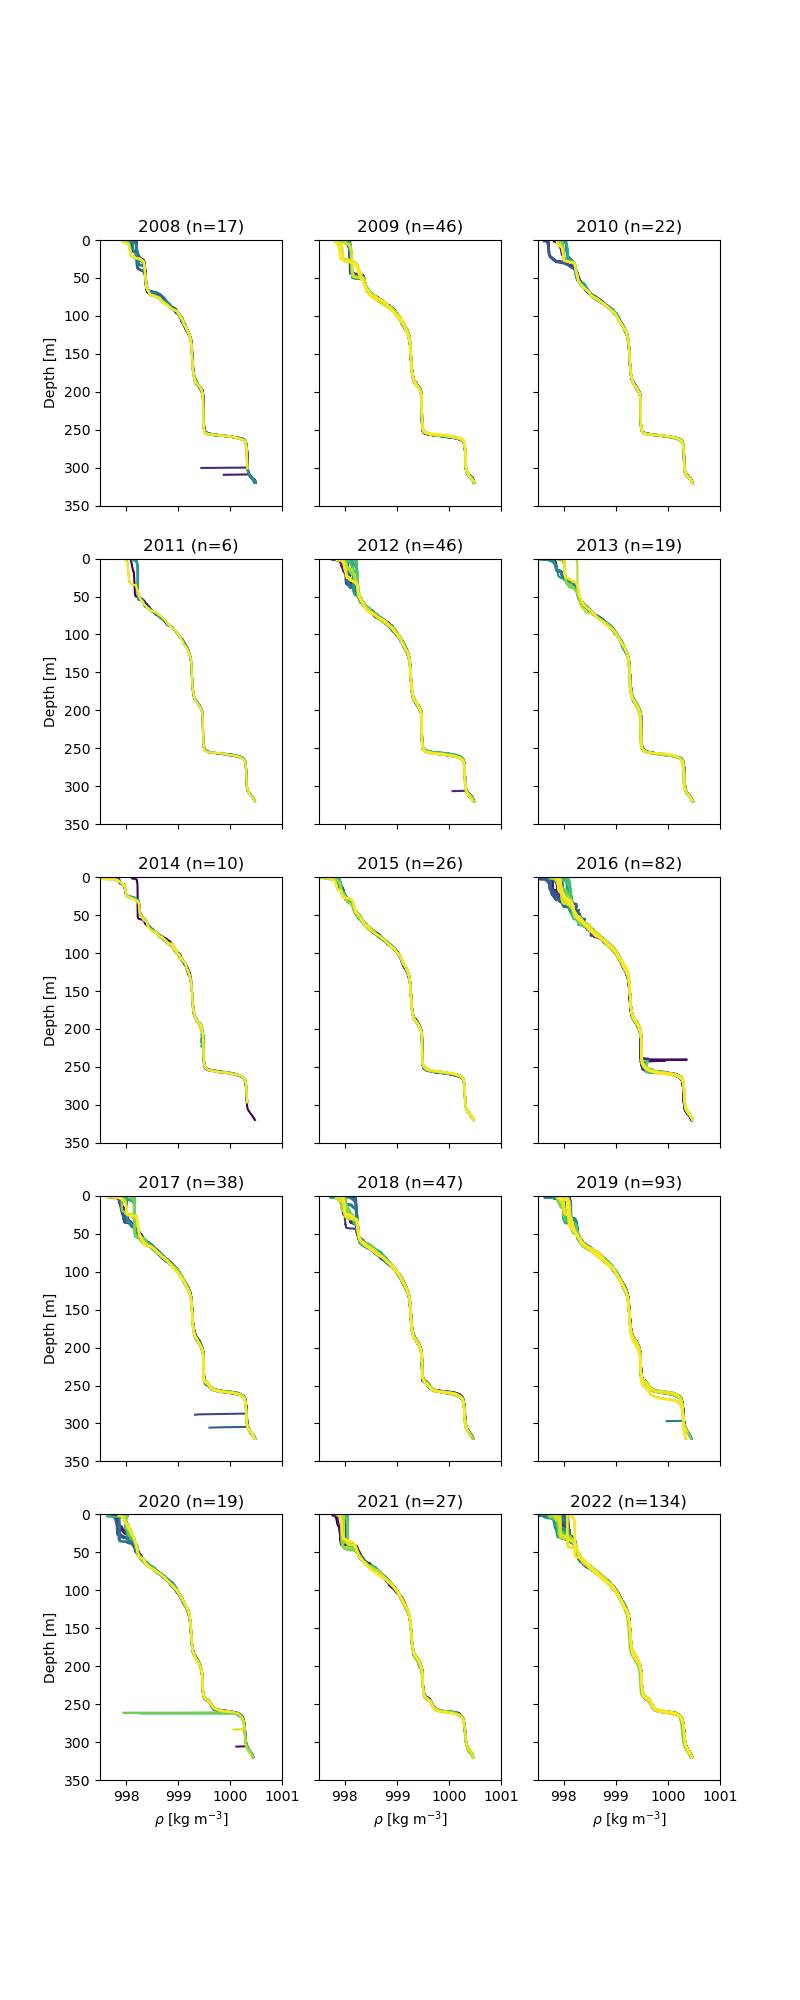

In [37]:
tyear=np.arange(2008,2023,1)
ylimval=[0,350]
xlimval=[997.5,1001]
fig,ax = plt.subplots(math.ceil(len(tyear)/3),3,figsize=(8,20),sharex='all',sharey='all')
count=0
drho=0

for kyear in tyear:
    pdens=[]
    krow=math.floor(count/3)
    kcol=count%3 # Modulo
    rhoyear=rho_all[:,np.logical_and(t_date_all>=datetime(tyear[count],1,1),t_date_all<datetime(tyear[count]+1,1,1))]
    dateyear=t_date_all[np.logical_and(t_date_all>=datetime(tyear[count],1,1),t_date_all<datetime(tyear[count]+1,1,1))]
    doy=[i.timetuple().tm_yday for i in dateyear]
    doyunique,doyind,=np.unique(doy,return_index=True)
    Cmap=plt.get_cmap('viridis',len(rhoyear[0,:]))
    for kprof in np.arange(len(rhoyear[0,:])):
        hplot,=ax[krow,kcol].plot(rhoyear[:,kprof]+kprof*drho,d_all,color=Cmap(kprof))
        pdens.append(hplot)
    ax[krow,kcol].set_title(str(kyear)+" (n="+str(len(rhoyear[0,:]))+")")
    ax[krow,kcol].set_ylim(ylimval[0],ylimval[1])
    ax[krow,kcol].set_xlim(xlimval[0],xlimval[1])
    ax[krow,kcol].invert_yaxis()
    if kcol==0:
        ax[krow,kcol].set_ylabel('Depth [m]')
    if krow==math.ceil(len(tyear)/3)-1:
        ax[krow,kcol].set_xlabel('$\\rho$ [kg m$^{-3}$]')
    #indselect=np.linspace(0,len(rhoyear[0,:])-1,5).astype(int)
    indselect=doyind
    #ax[krow,kcol].legend(handles=[pdens[i] for i in  indselect],labels=[dateyear[i].strftime('%d %b') for i in  indselect],fontsize=8)
    count=count+1

In [129]:
fig.savefig("Figures/profiles_all_d"+str(dmin)+"m.png",dpi=400)

### Figure for selected profiles

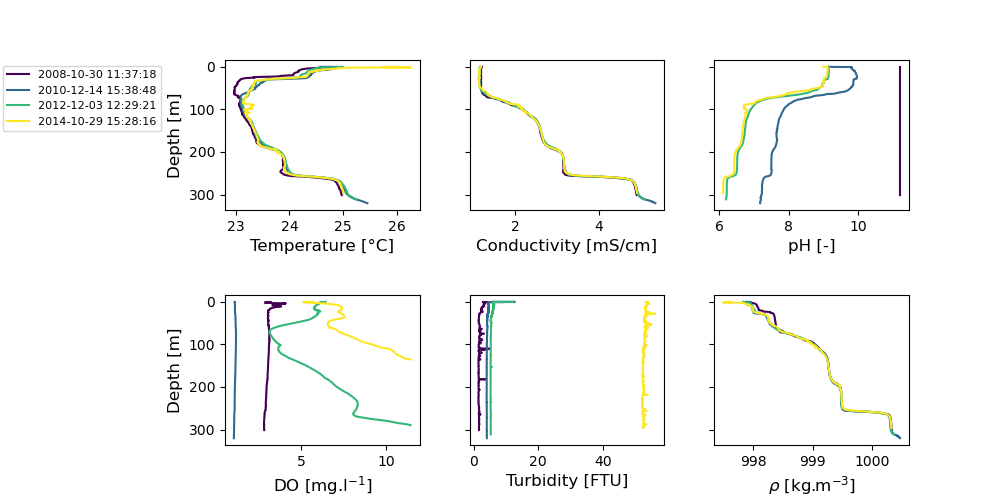

In [76]:
fig,ax = plt.subplots(2,3,figsize=(10,5),sharey=True)
ptemp=[]
dx=0.1 # To shift axes
dy=0.05
# ind_select=[0,70,120,150]
# t_date=[t_date_all[i] for i in ind_select]
date_chosen=[datetime(2009,1,1),datetime(2011,1,1),datetime(2013,1,1),datetime(2015,1,1)] # Choose dates
ind_select=np.full(len(date_chosen),0) 
k=0
for date_val in date_chosen: # Get index of the profile taken the closest from the chosen date
    ind_select[k]=np.argmin(np.abs(np.array(t_date_all)-date_chosen[k]))
    k=k+1
date_select=list(np.array(t_date_all)[ind_select])

Cmap=plt.get_cmap('viridis',len(ind_select))
kprof=0

for indprof in ind_select:
    
    hplot,=ax[0,0].plot(temp_all[:,indprof],d,color=Cmap(kprof))
    ptemp.append(hplot)
    
    if indprof==ind_select[-1]:
        ax[0,0].set_xlabel('Temperature [°C]',fontsize=12)
        ax[0,0].set_ylabel('Depth [m]',fontsize=12)
#         ax[0,0].tick_params(axis='x', labelsize=12)
#         ax[0,0].tick_params(axis='y', labelsize=12)
        ax[0,0].legend(handles=ptemp,labels=date_select,loc='upper right',bbox_to_anchor=(-0.3,1),fontsize=8)
        axpos0=ax[0,0].get_position()
        axpos_new=[axpos0.x0+dx,axpos0.y0+dy,axpos0.width-dx/3,axpos0.height-dy]
        ax[0,0].set_position(axpos_new)
        ax[0,0].invert_yaxis() # Only do it for first y-axis as all the y-axes are linked by sharey option
    
    ax[0,1].plot(cond_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[0,1].set_xlabel('Conductivity [mS/cm]',fontsize=12)
        ax[0,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,1].invert_yaxis()
    
    ax[0,2].plot(pH_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[0,2].set_xlabel('pH [-]',fontsize=12)
        ax[0,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,2].invert_yaxis()
    
    ax[1,0].plot(DO_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[1,0].set_xlabel('DO [mg.l$^{-1}$]',fontsize=12)
        ax[1,0].set_ylabel('Depth [m]',fontsize=12)
        axpos1=ax[1,0].get_position()
        ax[1,0].set_position([axpos_new[0],axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,0].invert_yaxis()
    
    ax[1,1].plot(turb_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[1,1].set_xlabel('Turbidity [FTU]',fontsize=12)
        ax[1,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,1].invert_yaxis()
    
    ax[1,2].plot(rho_all[:,indprof],d,color=Cmap(kprof))
    if indprof==ind_select[-1]:
        ax[1,2].set_xlabel('$\\rho$ [kg.m$^{-3}$]',fontsize=12)
        ax[1,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,2].invert_yaxis()
    kprof=kprof+1
    

fig.savefig("Figures/profiles_examples.png")

# 4.Single profile files (Level 2A)

In [31]:
foldername='../data/Level2A_TD/'
#filename_list=os.listdir(foldername)
filename_list=['L2A_20081009_112929.nc']

## 4.1. Time series during profiling

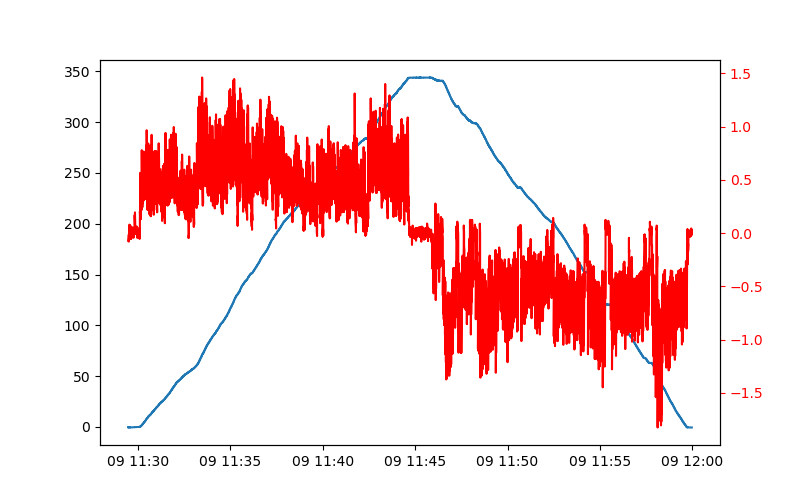

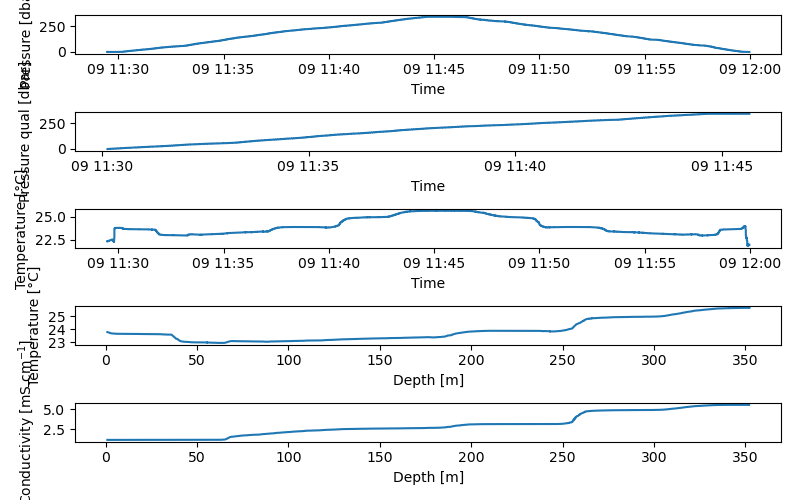

In [33]:
ind_dt=10
fig1,ax1=plt.subplots(figsize=(8,5))
ax1_right = ax1.twinx()
fig2,ax2=plt.subplots(5,1,figsize=(8,5))
    
for kfile in np.arange(0,len(filename_list),1):
    nc=netCDF4.Dataset(foldername+filename_list[kfile], mode='r', format='NETCDF4_CLASSIC')
    t = nc.variables["time"][:]
    temp = nc.variables["Temp"][:]
    cond=nc.variables["Cond"][:]
    press = nc.variables["Press"][:]
    salin=nc.variables["SALIN"][:]
    press_qual = nc.variables["Press_qual"][:]
    depth = nc.variables["depth"][:]
    # print(nc)    
    
    t_date= np.array([datetime.utcfromtimestamp(k) for k in t.data])
    #t_date= [datetime.fromtimestamp(k) for k in t.data]

    ax1.plot(t_date,press)
    t_diff=(t_date[ind_dt:]-t_date[:-ind_dt])
    t_diff_sec=np.array([t_diff[i].total_seconds() for i in np.arange(len(t_diff))])
    ax1_right.plot(t_date[ind_dt:],(press[ind_dt:]-press[:-ind_dt])/t_diff_sec,'r')
    #ax1_right.yaxis.label.set_color('red')
    ax1_right.tick_params(axis='y', colors='red')
    
    ax2[0].plot(t_date,press)
    ax2[1].plot(t_date[press_qual==0],press[press_qual==0])
    #ax2[0].set(xlabel='Time',ylabel='Pressure [dbar]',title=nc.file_name)
    ax2[2].plot(t_date,temp)    
    ax2[3].plot(depth,temp)
    ax2[4].plot(depth,cond)

    nc.close()
ax2[0].set(xlabel='Time',ylabel='Pressure [dbar]')
ax2[1].set(xlabel='Time',ylabel='Pressure qual [dbar]')
ax2[2].set(xlabel='Time',ylabel='Temperature [°C]')
ax2[3].set(xlabel='Depth [m]',ylabel='Temperature [°C]')
ax2[4].set(xlabel='Depth [m]',ylabel='Conductivity [mS.cm$^{-1}$]')
fig2.set_tight_layout(True)
    

## 4.2. Density calculation

### Load gases profiles

In [67]:
df_gas=pd.read_excel('..\data\gas_profile\Gas_profile.xlsx',names=['Depth','CH4','CH4_err','CO2','CO2_err'])
C_CH4=df_gas["CH4"][~np.isnan(df_gas["CH4"])]*16/1000 # g/L
C_CO2= df_gas["CO2"][~np.isnan(df_gas["CO2"])]*44/1000 # g/L
d_CH4=df_gas["Depth"][~np.isnan(df_gas["CH4"])]
d_CO2=df_gas["Depth"][~np.isnan(df_gas["CO2"])]
C_CH4_interp=np.interp(depth, d_CH4, C_CH4) # g/L
C_CO2_interp=np.interp(depth, d_CO2, C_CO2) # g/L

In [68]:
rho_TS=density(temp,salin)
rho_TS_CH4=density(temp,salin,C_CH4_interp)
rho_TS_CH4_CO2=density(temp,salin,C_CH4_interp,C_CO2_interp)

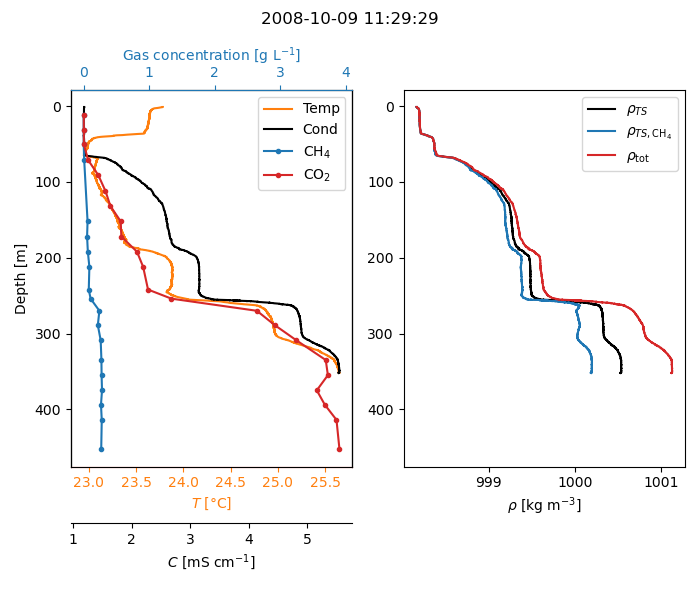

In [106]:
fig,ax=plt.subplots(1,2,figsize=(7,6))

ptemp,=ax[0].plot(temp,depth,'C1')
ax[0].invert_yaxis()
ax[0].set_xlabel('$T$ [°C]',color='C1')
ax[0].spines.bottom.set_color('r')
ax[0].tick_params(axis='x', colors='C1')
ax[0].set_ylabel('Depth [m]')

axsalin=ax[0].twiny()
axsalin.xaxis.set_ticks_position("bottom")
axsalin.xaxis.set_label_position("bottom")
axsalin.spines.bottom.set_position(("axes", -0.15))
#axsalin.plot(salin,depth,'k')
pcond,=axsalin.plot(cond,depth,color='k')
axsalin.set_xlabel('$C$ [mS cm$^{-1}$]',color='k')

axgas=ax[0].twiny()
pCH4,=axgas.plot(C_CH4,d_CH4,'.-',color='C0')
pCO2,=axgas.plot(C_CO2,d_CO2,'.-',color='C3')
axgas.spines.top.set_color('C0')
axgas.tick_params(axis='x', colors='C0')
#axgas.set_xlabel('C$_{\\rm CH_{4}}$, C$_{\\rm CO_{2}}$ [g L$^{-1}$]',color='b')
axgas.set_xlabel('Gas concentration [g L$^{-1}$]',color='C0')

axgas.legend([ptemp,pcond,pCH4,pCO2],['Temp','Cond','CH$_4$','CO$_2$'])
ylimval=ax[0].get_ylim()


ax[1].plot(rho_TS,depth,'k')
ax[1].plot(rho_TS_CH4,depth,'C0')
ax[1].plot(rho_TS_CH4_CO2,depth,'C3')
ax[1].invert_yaxis()
ax[1].set_ylim(ylimval)
ax[1].set_xlabel('$\\rho$ [kg m$^{-3}$]')
ax[1].legend(['$\\rho_{TS}$','$\\rho_{TS,\\rm{CH_4}}$','$\\rho_{\\rm tot}$'])


fig.suptitle(str(t_date[0]))
plt.tight_layout()

In [109]:
fig.savefig("Figures/density_profiles_"+t_date[0].strftime('%Y%m%d')+".png",dpi=400)

# 5. Profiles from a monthly file (Level 2B)

### Open the file

In [41]:
kfile=np.where(np.array(files)=='L2B_20201101_000000.nc')[0][0]
nc=netCDF4.Dataset(os.path.join(folder, files[kfile]), mode='r', format='NETCDF4_CLASSIC')
press=nc.variables["Press"][:]
temp = nc.variables["Temp"][:]
cond = nc.variables["Cond"][:]
turb = nc.variables["Turb"][:]
pH = nc.variables["pH"][:]
DO = nc.variables["DO_mg"][:]
rho = nc.variables["rho"][:]
depth=nc.variables["depth"][:]
t = nc.variables["time"][:] 
d = nc.variables["depth_ref"][:]
lat=nc.variables["latitude"][:]
long=nc.variables["longitude"][:]
dist_GEF=nc.variables["dist_GEF"][:]
#print(nc)
nc.close()
t_date = [datetime.utcfromtimestamp(k) for k in t.data]

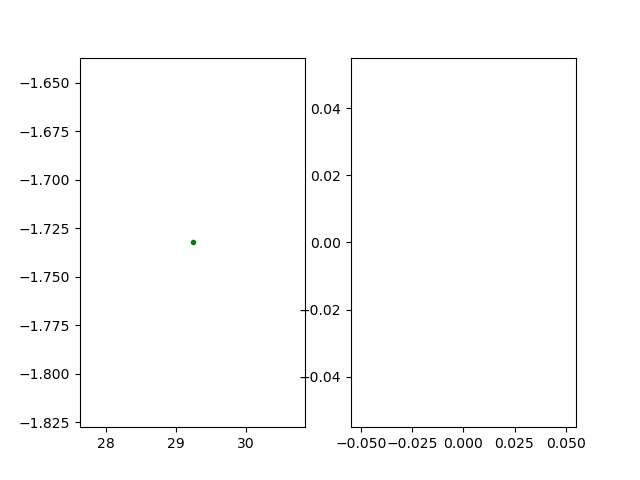

In [42]:
fig,ax=plt.subplots(1,2)
ax[0].plot(long,lat,'k.')
#ax.plot(coord_KivuWatt[0],coord_KivuWatt[1],'.r')
ax[0].plot(coord_KP1[0],coord_KP1[1],'.g')

ax[1].plot(np.arange(len(dist_GEF)),dist_GEF,'k.')

### Plot one profile from the file

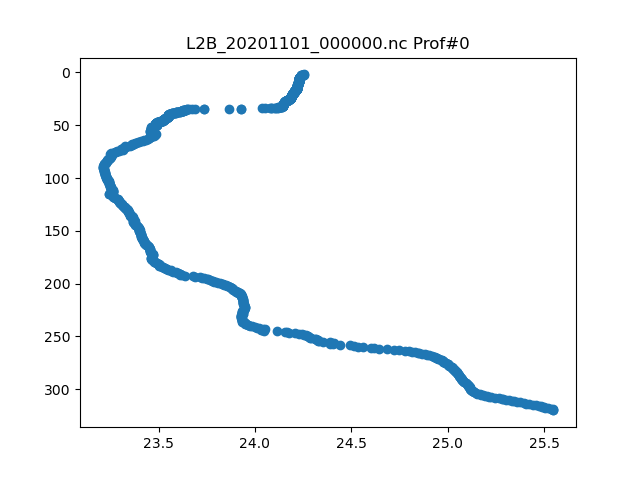

In [49]:
tdata=t
#indafter=np.where(t>datetime(2008,10,25,0,0,0).timestamp())[0][0]
indafter=0
tempval=temp[:,indafter].data
fig,ax=plt.subplots()
ax.plot(tempval,d,'o')
ax.set_title(files[kfile]+' Prof#'+str(indafter))
ax.invert_yaxis()

### Plot all the profiles from the file

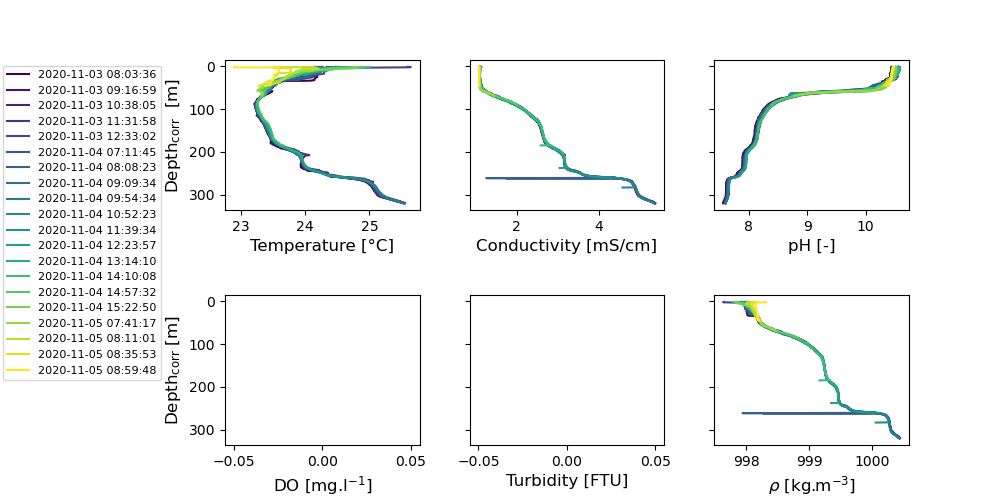

In [36]:
# interactive inline:
#%matplotlib widget 
#separate window:
#%matplotlib qt
fig,ax = plt.subplots(2,3,figsize=(10,5),sharey=True)
ptemp=[]
dx=0.1 # To shift axes
dy=0.05
Cmap=plt.get_cmap('viridis',len(t))
step_legend=1
count=-1
indprof_select=np.arange(len(t))
# t0=datetime(2020,11,4,8,0,0).replace(tzinfo=timezone.utc).timestamp()
# tf=datetime(2020,11,4,9,0,0).replace(tzinfo=timezone.utc).timestamp()
# indprof_select=np.where(np.logical_and(t>=t0,t<=tf))[0]

for indprof in indprof_select:
    count=count+1
    hplot,=ax[0,0].plot(temp[:,indprof],d,color=Cmap(indprof))
    ptemp.append(hplot)
    
    if count==len(indprof_select)-1: #Last profile
        ax[0,0].set_xlabel('Temperature [°C]',fontsize=12)
        ax[0,0].set_ylabel('Depth$_{\\rm corr}$  [m]',fontsize=12)
#         ax[0,0].tick_params(axis='x', labelsize=12)
#         ax[0,0].tick_params(axis='y', labelsize=12)
        ax[0,0].legend(handles=[ptemp[i] for i in np.arange(0,len(indprof_select),step_legend)],labels=[t_date[i] for i in indprof_select[np.arange(0,len(indprof_select),step_legend)]],loc='upper right',bbox_to_anchor=(-0.3,1),fontsize=8)
        axpos0=ax[0,0].get_position()
        axpos_new=[axpos0.x0+dx,axpos0.y0+dy,axpos0.width-dx/3,axpos0.height-dy]
        ax[0,0].set_position(axpos_new)
        ax[0,0].invert_yaxis() # Only do it for first y-axis as all the y-axes are linked by sharey option
    
    ax[0,1].plot(cond[:,indprof],d,color=Cmap(indprof))
    if count==len(indprof_select)-1:
        ax[0,1].set_xlabel('Conductivity [mS/cm]',fontsize=12)
        ax[0,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,1].invert_yaxis()
    
    ax[0,2].plot(pH[:,indprof],d,color=Cmap(indprof))
    if count==len(indprof_select)-1:
        ax[0,2].set_xlabel('pH [-]',fontsize=12)
        ax[0,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos_new[1],axpos_new[2],axpos_new[3]])
        #ax[0,2].invert_yaxis()
    
    ax[1,0].plot(DO[:,indprof],d,color=Cmap(indprof))
    if count==len(indprof_select)-1:
        ax[1,0].set_xlabel('DO [mg.l$^{-1}$]',fontsize=12)
        ax[1,0].set_ylabel('Depth$_{\\rm corr}$ [m]',fontsize=12)
        axpos1=ax[1,0].get_position()
        ax[1,0].set_position([axpos_new[0],axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,0].invert_yaxis()
    
    ax[1,1].plot(turb[:,indprof],d,color=Cmap(indprof))
    if count==len(indprof_select)-1:
        ax[1,1].set_xlabel('Turbidity [FTU]',fontsize=12)
        ax[1,1].set_position([axpos_new[0]+axpos_new[2]+0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,1].invert_yaxis()
    
    ax[1,2].plot(rho[:,indprof],d,color=Cmap(indprof))
    if count==len(indprof_select)-1:
        ax[1,2].set_xlabel('$\\rho$ [kg.m$^{-3}$]',fontsize=12)
        ax[1,2].set_position([axpos_new[0]+2*axpos_new[2]+2*0.05,axpos1.y0,axpos_new[2],axpos_new[3]])
        #ax[1,2].invert_yaxis()



In [17]:
## fig.savefig("Figures/profiles_"+files[kfile][4:-3]+".png",dpi=400)

### Compare pressure, depth, depth corrected

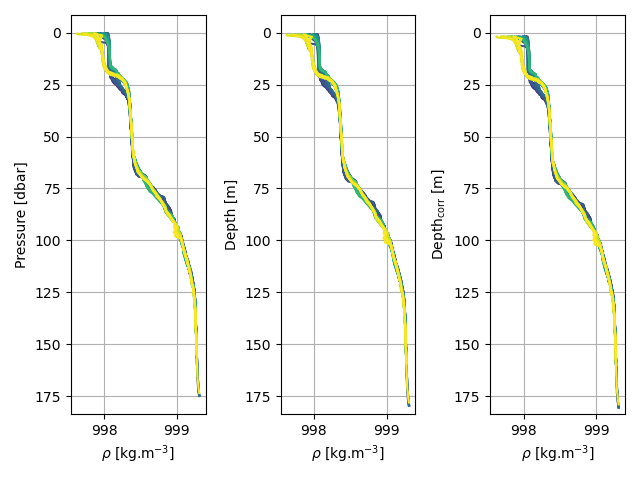

In [10]:
fig,ax = plt.subplots(1,3)

for indprof in np.arange(len(t)):
    ax[0].plot(rho[:,indprof],press[:,indprof],color=Cmap(indprof))
    ax[1].plot(rho[:,indprof],depth[:,indprof],color=Cmap(indprof))
    ax[2].plot(rho[:,indprof],d,color=Cmap(indprof))
ax[0].invert_yaxis()
ylimval=ax[0].get_ylim()
xlimval=ax[0].get_xlim()
# ax[0].plot(list(xlimval),[0,0],'--k')
ax[0].set_xlim(xlimval)
ax[0].set_xlabel('$\\rho$ [kg.m$^{-3}$]')
ax[0].set_ylabel('Pressure [dbar]')
ax[0].grid()

ax[1].invert_yaxis()
# ax[1].plot(list(xlimval),[0,0],'--k')
ax[1].set_xlim(xlimval)
ax[1].set_ylim(ylimval)
ax[1].set_xlabel('$\\rho$ [kg.m$^{-3}$]')
ax[1].set_ylabel('Depth [m]')
ax[1].grid()

ax[2].invert_yaxis()
# ax[2].plot(list(xlimval),[0,0],'--k')
ax[2].set_xlim(xlimval)
ax[2].set_ylim(ylimval)
ax[2].set_xlabel('$\\rho$ [kg.m$^{-3}$]')
ax[2].set_ylabel('Depth$_{\\rm corr}$ [m]')
ax[2].grid()

plt.tight_layout()

#fig.savefig("Figures/profiles_Nov2008_press_depth.png",dpi=400)

### Profiles as a function of pressure

Text(0, 0.5, 'Pressure [dbar]')

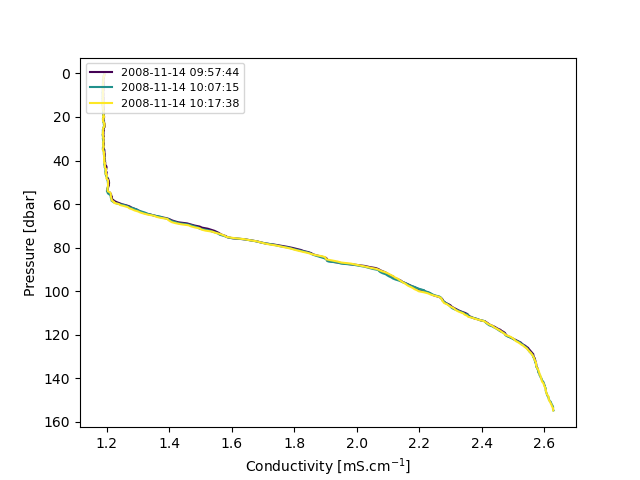

In [11]:
selectprof=np.arange(27,30,1)

fig,ax=plt.subplots()
Cmap2=plt.get_cmap('viridis',len(selectprof))
for indprof in selectprof:
    ax.plot(cond[:,indprof],press[:,indprof],color=Cmap2(np.where(selectprof==indprof)[0][0]))
ax.legend(labels=[t_date[i] for i in selectprof],loc='upper left',fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Conductivity [mS.cm$^{-1}$]')
ax.set_ylabel('Pressure [dbar]')